# NanoHUB-PADRE Tutorial Series
## Semiconductor Device Simulation — from textbook equations to a real simulator

These notebooks teach semiconductor device physics by putting **two things side by side**:

1. the **textbook model** of a device — the closed-form equations you meet in Sze & Ng, Pierret, Taur & Ning or Streetman, and
2. a **numerical simulation** of the same device with PADRE, a 2-D drift-diffusion simulator developed at Purdue.

The two never agree perfectly, and *that is the lesson*. Every textbook formula rests on assumptions
(abrupt depletion edges, no series resistance, a one-dimensional device, constant mobility, ideal contacts, ...).
A simulator makes far fewer assumptions. When the numbers differ, each notebook states **exactly what is
different and why**, so you learn what every formula leaves out and when it can be trusted.

The `nanohubpadre` Python library writes PADRE's input deck for you, runs PADRE, and reads the results back
as NumPy arrays, so you can focus on the physics.

---
## 1. What a device simulator actually solves

PADRE solves the **drift-diffusion equations** self-consistently on a 2-D mesh. For electron density $n$,
hole density $p$ and electrostatic potential $\psi$:

**Poisson's equation** (charge creates potential)
$$\nabla\cdot(\varepsilon\nabla\psi) = -q\,(p - n + N_D^+ - N_A^-)$$

**Current continuity** (carriers are conserved, apart from generation $G$ and recombination $R$)
$$\frac{\partial n}{\partial t} = \frac{1}{q}\nabla\cdot\mathbf J_n + G - R, \qquad
  \frac{\partial p}{\partial t} = -\frac{1}{q}\nabla\cdot\mathbf J_p + G - R$$

**Drift-diffusion current** (carriers drift in the field and diffuse down concentration gradients)
$$\mathbf J_n = q\mu_n n\,\mathbf E + qD_n\nabla n, \qquad \mathbf J_p = q\mu_p p\,\mathbf E - qD_p\nabla p,
  \qquad D = \mu\,\frac{kT}{q}\ \text{(Einstein relation)}$$

Everything else is a **model** plugged into these equations:

| Model keyword | Physics | Typical formula |
|---|---|---|
| `srh` | Shockley-Read-Hall recombination through mid-gap traps | $R=\dfrac{np-n_i^2}{\tau_p(n+n_1)+\tau_n(p+p_1)}$ |
| `auger` | Auger recombination (important above ~1e19 cm⁻³) | $R=(C_n n + C_p p)(np-n_i^2)$ |
| `conmob` | mobility falls with doping (ionized-impurity scattering) | Masetti / Caughey-Thomas fits |
| `fldmob` | velocity saturation at high field | $v=\dfrac{\mu E}{[1+(\mu E/v_{sat})^\beta]^{1/\beta}}$ |
| `gatmob` | mobility reduction by the transverse gate field (MOSFETs) | surface-roughness / phonon terms |
| `bgn` | band-gap narrowing in heavily doped silicon | Slotboom model |

**How it is solved.** The device is divided into a mesh of nodes. Currents between neighbouring nodes use the
**Scharfetter-Gummel** discretization (exact for an exponential carrier profile), and the resulting nonlinear
system is solved by **Newton's method** at each bias point. Each new bias point starts from a guess:
`PREV` (the previous solution) or `PROJ` (a linear extrapolation from the two previous solutions).
The library chooses these for you. Notebook 01 explains why the choice matters.

---
## 2. Units you will see everywhere

PADRE simulates a **2-D cross-section** (x, y). The third dimension (z, into the page) is treated as uniform with
depth `width` = 1 µm unless you change it (`device_z_width=` in the factories). Therefore:

| Quantity | PADRE unit | To get an absolute value |
|---|---|---|
| terminal current | A **per µm of depth** | multiply by the device depth in µm |
| capacitance | F **per µm of depth** | multiply by the depth in µm |
| lengths in decks | µm | — |
| doping | cm⁻³ | — |

Textbook formulas are usually written per cm² of junction area. To compare, multiply by the simulated area,
e.g. a 1 µm-tall diode that is 1 µm deep has $A = 10^{-8}\ \text{cm}^2$.

---
## 3. The constants PADRE uses are not always the textbook ones

Before comparing anything, look at the material constants. The cell below prints the values PADRE really uses
next to the classic textbook values. **Every notebook in this series uses PADRE's values in its
analytic formulas**, so that when theory and simulation disagree, the difference is physics or modelling,
not a mismatched constant.

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────
# PADRE is a compiled simulator. On nanoHUB it lives in an environment
# module that must be loaded into this Python kernel before the first
# simulation runs; elsewhere, PADRE just needs to be on your PATH.
import shutil
from nanohubpadre import use

if shutil.which("padre") is None:
    try:
        use("padre-2.4E-r15")          # nanoHUB module name
    except Exception as exc:           # not on nanoHUB: that is fine
        print("Could not load the PADRE module:", exc)

print("PADRE executable:", shutil.which("padre") or "NOT FOUND - simulations will fail")

PADRE executable: /apps/share64/debian10/padre/padre-2.4E/r15/bin/padre


In [2]:
# ── Physical constants: textbook values vs. the values PADRE really uses ──
# PADRE prints its constants with `MODELS ... PRINT`. A fair comparison of
# simulation against a formula must feed the formula PADRE's numbers:
# e.g. the textbook n_i = 1.5e10 cm^-3 alone changes every analytic diode
# current by (1.5e10 / 9.963e9)^2 = 2.3x before any physics is compared.
import numpy as np

Q      = 1.602e-19        # elementary charge (C)
KT     = 0.025851         # thermal voltage kT/q at 300 K (V)
EPS0   = 8.854e-14        # vacuum permittivity (F/cm)
EPS_SI = 11.8 * EPS0      # silicon permittivity in PADRE (F/cm)
EPS_OX = 3.9 * EPS0       # SiO2 permittivity (F/cm)
NI     = 9.963e9          # intrinsic carrier density of Si at 300 K (cm^-3)
EG     = 1.12             # band gap (eV)
CHI_SI = 4.17             # electron affinity of Si in PADRE (eV)
NC, NV = 3.2e19, 2.03e19  # effective densities of states (cm^-3)

# The values most textbooks quote (e.g. Sze & Ng, Pierret), for contrast.
TEXTBOOK = dict(NI=1.5e10, EPS_SI=11.7 * EPS0, CHI_SI=4.05, NC=2.8e19, NV=1.04e19)


def compare(rows, title="Textbook vs. PADRE"):
    """Print a comparison table.

    rows: list of (quantity, textbook_value, padre_value, unit, why_different)
    """
    print(title)
    print("-" * 125)
    print(f"{'quantity':<40}{'textbook':>12}{'PADRE':>12}{'diff':>9}   why they differ")
    print("-" * 125)
    for name, tb, pd, unit, why in rows:
        d = f"{(pd - tb) / tb * 100:>+8.1f}%" if tb else "     n/a "
        print(f"{name + ' (' + unit + ')':<40}{tb:>12.4g}{pd:>12.4g}{d}   {why}")
    print("-" * 125)


compare([
    ("intrinsic density n_i", TEXTBOOK["NI"], NI, "cm^-3",
     "modern value (Sproul & Green 1991); 1.5e10 is the older textbook number"),
    ("Si permittivity", TEXTBOOK["EPS_SI"], EPS_SI, "F/cm", "PADRE uses eps_r = 11.8, Sze uses 11.7"),
    ("electron affinity chi", TEXTBOOK["CHI_SI"], CHI_SI, "eV", "PADRE (like Silvaco Atlas) uses 4.17"),
    ("conduction-band DOS Nc", TEXTBOOK["NC"], NC, "cm^-3", "different effective-mass fit"),
    ("valence-band DOS Nv", TEXTBOOK["NV"], NV, "cm^-3", "different effective-mass fit"),
], title="Material constants")

Material constants
-----------------------------------------------------------------------------------------------------------------------------
quantity                                    textbook       PADRE     diff   why they differ
-----------------------------------------------------------------------------------------------------------------------------
intrinsic density n_i (cm^-3)                1.5e+10   9.963e+09   -33.6%   modern value (Sproul & Green 1991); 1.5e10 is the older textbook number
Si permittivity (F/cm)                     1.036e-12   1.045e-12    +0.9%   PADRE uses eps_r = 11.8, Sze uses 11.7
electron affinity chi (eV)                      4.05        4.17    +3.0%   PADRE (like Silvaco Atlas) uses 4.17
conduction-band DOS Nc (cm^-3)               2.8e+19     3.2e+19   +14.3%   different effective-mass fit
valence-band DOS Nv (cm^-3)                 1.04e+19    2.03e+19   +95.2%   different effective-mass fit
---------------------------------------------------

The biggest trap is $n_i$. Many diode, BJT and MOS formulas contain $n_i^2$, so using the older value
$1.5\times10^{10}$ instead of PADRE's $9.96\times10^{9}$ changes a predicted saturation current by a factor
of **2.3** and a built-in potential by about **21 mV**. Similarly, a Schottky barrier computed as
$\phi_m - 4.05$ eV is **0.12 eV** higher than the barrier PADRE builds ($\phi_m - 4.17$ eV). That is a factor of
$e^{0.12/0.0259}\approx 100$ in thermionic current.

In [3]:
# How much do the constants alone move two classic results?
import numpy as np
Na = Nd = 1e17
vbi_textbook = KT * np.log(Na * Nd / TEXTBOOK["NI"] ** 2)
vbi_padre    = KT * np.log(Na * Nd / NI ** 2)

phi_m = 4.8                              # a metal work function (eV)
phib_textbook = phi_m - TEXTBOOK["CHI_SI"]
phib_padre    = phi_m - CHI_SI

compare([
    ("built-in potential Vbi", vbi_textbook, vbi_padre, "V",
     "only n_i differs: Vbi = kT/q ln(NaNd/n_i^2)"),
    ("saturation-current factor n_i^2", TEXTBOOK["NI"] ** 2, NI ** 2, "cm^-6",
     "diode/BJT currents scale with n_i^2"),
    ("Schottky barrier phi_B", phib_textbook, phib_padre, "eV",
     "phi_B = phi_m - chi, and chi differs"),
], title="Same formula, different constants")

Same formula, different constants
-----------------------------------------------------------------------------------------------------------------------------
quantity                                    textbook       PADRE     diff   why they differ
-----------------------------------------------------------------------------------------------------------------------------
built-in potential Vbi (V)                    0.8124      0.8335    +2.6%   only n_i differs: Vbi = kT/q ln(NaNd/n_i^2)
saturation-current factor n_i^2 (cm^-6)     2.25e+20   9.926e+19   -55.9%   diode/BJT currents scale with n_i^2
Schottky barrier phi_B (eV)                     0.75        0.63   -16.0%   phi_B = phi_m - chi, and chi differs
-----------------------------------------------------------------------------------------------------------------------------


---
## 4. The tutorial notebooks

| # | Notebook | Device | What you will compare with the textbook |
|---|---|---|---|
| 01 | [Library Overview](01_Library_Overview.ipynb) | — | how a PADRE deck is built; solve sequencing; checking a result |
| 02 | [PN Junction Diode](02_PN_Diode.ipynb) | p-n diode | $V_{bi}$, depletion width, Shockley equation (short and long base), ideality factor, SRH $n\to2$ |
| 03 | [Schottky Diode](03_Schottky_Diode.ipynb) | metal/n-Si | barrier height, thermionic emission vs. thermionic-emission-diffusion (Crowell-Sze), Richardson constant |
| 04 | [MOSFET](04_MOSFET.ipynb) | n-MOSFET | threshold voltage, subthreshold swing, DIBL, mobility, velocity-saturated $I_{dsat}$, 1/L scaling |
| 05 | [BJT](05_BJT.ipynb) | n-p-n | Gummel plot, $\beta$ from Gummel numbers, Early voltage, high-injection roll-off |
| 06 | [MOS Capacitor](06_MOS_Capacitor.ipynb) | MOS stack | exact classical C-V, $C_{ox}$, $C_{min}$, flat-band, HF vs. low-frequency (quasi-static) C-V |
| 07 | [MESFET](07_MESFET.ipynb) | n-MESFET | pinch-off voltage, gradual-channel model, short-channel limits ($L_g/a$) |
| 08 | [NIN / PIP Diode](08_NIN_Diode.ipynb) | isotype diode | ohmic conduction, space-charge-limited current (Mott-Gurney), symmetry |
| 09 | [Validating a Simulator](09_Validating_a_Simulator.ipynb) | test structures | $n_i$, mobility vs. doping, velocity saturation, mesh convergence, current continuity |
| 10 | [The pntoy Diode: Band Diagrams Under Bias](10_pntoy_Band_Diagrams.ipynb) | p-n diode (nanoHUB pntoy) | textbook band diagram at low bias; high injection, ohmic drop and the $V_{bi}$ wall at high bias |
| 11 | [Keeping the Textbook Picture](11_Keeping_the_Textbook_Picture.ipynb) | p-n diode designs | which knobs (doping, length, area, lifetime, temperature) extend the bias range where the textbook holds |

**Suggested path:** 01 → 02 → 03, then 06 before 04 (the MOS capacitor explains the MOSFET gate), then 05, 07, 08.
Notebook 09 is for anyone who wants to know *how we know* the simulator is right.
Notebooks 10 and 11 return to the p-n diode through the nanoHUB **pntoy** tool, and are a good follow-up to 02.

---
## 5. A first simulation

Let's simulate a silicon p-n diode (1e17 cm⁻³ on both sides) at equilibrium, then compare its built-in
potential with the textbook formula. The comparison uses PADRE's $n_i$, so they should agree to a fraction of a millivolt.

In [4]:
from nanohubpadre import create_pn_diode

sim = create_pn_diode(
    length=1.0,          # total length (um); the junction sits at the centre
    p_doping=1e17,       # acceptors on the left (cm^-3)
    n_doping=1e17,       # donors on the right (cm^-3)
    log_bands_eq=True,   # write the equilibrium band diagram (Ec, Ev) along the device
)
result = sim.run()
print("PADRE finished with return code", result.returncode)

PADRE finished with return code 0


Built-in potential
-----------------------------------------------------------------------------------------------------------------------------
quantity                                    textbook       PADRE     diff   why they differ
-----------------------------------------------------------------------------------------------------------------------------
Vbi (PADRE n_i in formula) (V)                0.8335      0.8335    +0.0%   formula and simulator share n_i; agreement is expected
Vbi (textbook n_i in formula) (V)             0.8124      0.8335    +2.6%   the 21 mV gap is only the n_i value
-----------------------------------------------------------------------------------------------------------------------------


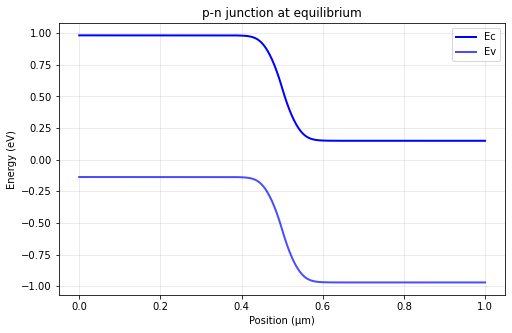

In [5]:
ec = sim.outputs.get("cbeq")          # conduction-band edge along the device
vbi_sim = abs(ec.y[0] - ec.y[-1])     # total band bending = q*Vbi
vbi_theory = KT * np.log(1e17 * 1e17 / NI ** 2)

compare([
    ("Vbi (PADRE n_i in formula)", vbi_theory, vbi_sim, "V",
     "formula and simulator share n_i; agreement is expected"),
    ("Vbi (textbook n_i in formula)", KT * np.log(1e34 / TEXTBOOK["NI"] ** 2), vbi_sim, "V",
     "the 21 mV gap is only the n_i value"),
], title="Built-in potential")
sim.plot_band_diagram(title="p-n junction at equilibrium");

---
## 6. Prerequisites and resources

* **Python** 3.8+ with `nanohubpadre`, `numpy`, `matplotlib`. On nanoHUB, everything including PADRE is installed.
* **Physics background**: a first course in semiconductor devices (energy bands, doping, drift and diffusion).

**References used throughout the series**
- S. M. Sze and K. K. Ng, *Physics of Semiconductor Devices*, 3rd ed., Wiley (2007)
- R. F. Pierret, *Semiconductor Device Fundamentals*, Addison-Wesley (1996)
- Y. Taur and T. H. Ning, *Fundamentals of Modern VLSI Devices*, 2nd ed., Cambridge (2009)
- S. Selberherr, *Analysis and Simulation of Semiconductor Devices*, Springer (1984)
- PADRE on nanoHUB: https://nanohub.org/resources/padre

**Next →** [01 — Library Overview](01_Library_Overview.ipynb)